In [2]:
#----- Initialize Python libraries ------

import pandas as pd
import numpy as np
import biogeme.database as db
import biogeme.biogeme as bio
import biogeme.models as models
from biogeme.expressions import Beta

# Set the option to display all columns
pd.set_option('display.max_columns', None)



In [96]:
#----- Edit of Wege File ------

na_values_to_treat_as_empty = ['', 'NA', 'N/A']  # Add any other values that represent empty cells
df_Wege_B3 = pd.read_csv('Datensatz/Datenstrukturierung/Transfer/Raw Data/B3_Datensatz_CSV/MiD2017_Lokal_Wege.csv',na_values=na_values_to_treat_as_empty)

# Keep only relevant columns
df_Wege_B3 = df_Wege_B3[['HP_ID_Lok','H_ID_Lok', 'P_ID','W_ID','ST_JAHR','ST_MONAT','ST_WOTAG','W_SZ','W_SZS','sz_gr1','zweck', 'hwzweck1', 'hvm_diff2', 'wetter','saison','wegmin_imp1', 'wegmin_imp1_gr','wegmin','wegkm','wegkm_imp','wegkm_imp_gr','weg_intermod','mobtyp','W_ANZBEGL', 'anzpers','GITTER_5km']] #Filter only for relevant columns 


# Create new column with explicit identifier for individual ways 
df_Wege_B3['Trip_ID'] = df_Wege_B3['HP_ID_Lok'].astype(str) + df_Wege_B3['W_ID'].astype(str)

# Convert the new column to integers
#df_Wege_B3['Trip_ID'] = df_Wege_B3['Trip_ID'].astype(int)

# Reorder columns with "Trip_ID" as the first column
desired_columns = ['Trip_ID'] + [col for col in df_Wege_B3.columns if col != 'Trip_ID']
df_Wege_B3 = df_Wege_B3[desired_columns]


# Save as new .csv file
#df_W2.to_csv('Wege_filtered_file.csv', index=False) #Save file as new csv file

df_Wege_B3.head()

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegmin,wegkm,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,15,9999.0,6.44,5,0,2,0,1,5kmN2885E4365
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,809,4,15,4,15,9999.0,6.44,5,0,2,0,1,5kmN2885E4365
2,100009031,10000903,10000900,3,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,70,9999.0,38.02,7,0,2,1,2,5kmN2885E4365
3,100009032,10000903,10000900,3,2,2016,11,3,15:30:00,15,6,8,3,13,809,4,100,8,100,9999.0,54.37,8,0,2,1,2,5kmN2885E4365
4,100009041,10000904,10000900,4,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,70,9999.0,38.25,7,0,2,1,2,5kmN2885E4365


In [97]:
#----- Edit of Haushalte File ------


# Read the data
df_Haushalte_B3 = pd.read_csv('Datensatz/Datenstrukturierung/Transfer/Raw Data/B3_Datensatz_CSV/MiD2017_Lokal_Haushalte.csv')
# Keep only relevant columns
df_Haushalte_B3 = df_Haushalte_B3[['H_ID_Lok','hhgr_gr2','anzauto_gr3','pedrad','oek_status','hhtyp2','PRAEZISION']] #Filter only for relevant columns 
# Save as new .csv file
#df_H2.to_csv('Haushalte_filtered_file.csv', index=False) #Save file as new csv file


In [98]:
#------ Edit of Personen File ------

# Read the data
df_Personen_B3 = pd.read_csv('Datensatz/Datenstrukturierung/Transfer/Raw Data/B3_Datensatz_CSV/MiD2017_Lokal_Personen.csv')

# Keep only relevant columns
df_Personen_B3 = df_Personen_B3[['HP_ID_Lok','P_VAUTO','P_VPED', 'P_VRAD', 'P_NUTZ_RAD','P_NUTZ_AUTO','P_NUTZ_CS','HP_SEX','alter_gr','P_FS_PKW','P_FS_MOP','taet','P_BIL','P_FKARTE']] #Filter only for relevant columns 


# Save as new .csv file
#df_P2.to_csv('Personen_filtered_file.csv', index=False) #Save file as new csv file

In [99]:
#------ Merging of tables (all trips) ------

df_merged_B3=df_Wege_B3.merge(df_Haushalte_B3, how="left", on="H_ID_Lok")
df_merged_B3=df_merged_B3.merge(df_Personen_B3, how="left", on="HP_ID_Lok")




Filter Location und Verfügbarkeit

In [102]:
df_merged_B3 = df_merged_B3[((df_merged_B3['P_VPED'] == 1) | (df_merged_B3['P_VRAD'] == 1)) & (df_merged_B3['P_VAUTO'] == 1)]

In [103]:
house_location = 'GITTER_5km'
df_filtered_B3 = df_merged_B3[df_merged_B3[house_location].apply(lambda x: isinstance(x, str) and x.strip() != '')]
df_filtered_B3 = df_filtered_B3[df_filtered_B3['PRAEZISION'].isin([1, 2])]
df_filtered_B3

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegmin,wegkm,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km,hhgr_gr2,anzauto_gr3,pedrad,oek_status,hhtyp2,PRAEZISION,P_VAUTO,P_VPED,P_VRAD,P_NUTZ_RAD,P_NUTZ_AUTO,P_NUTZ_CS,HP_SEX,alter_gr,P_FS_PKW,P_FS_MOP,taet,P_BIL,P_FKARTE
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,15,9999.00,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,809,4,15,4,15,9999.00,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1
12,100024011,10002401,10002400,1,1,2017,3,1,10:50:00,10,4,4,4,1,10,2,15,4,15,0.98,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1
13,100024012,10002401,10002400,1,2,2017,3,1,11:20:00,11,5,8,4,1,809,2,15,4,15,0.98,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1
16,100026611,10002661,10002660,1,1,2017,7,5,6:15:00,6,2,1,1,9,10,3,25,5,25,18.05,18.05,6,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,2,1,3,1,5,1,5,1,1,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960610,999992445,99999244,99999240,4,5,2016,12,5,18:45:00,18,7,7,6,1,809,1,5,2,5,0.98,0.98,2,0,2,0,1,5kmN2800E4315,4,2,1,2,3,1,1,2,1,4,3,5,1,2,1,1,2,1,1
960611,999992446,99999244,99999240,4,6,2016,12,5,20:55:00,20,8,8,6,1,809,1,5,2,5,0.98,0.98,2,0,2,0,1,5kmN2800E4315,4,2,1,2,3,1,1,2,1,4,3,5,1,2,1,1,2,1,1
960616,999994511,99999451,99999450,1,1,2016,11,5,8:10:00,8,3,2,2,13,10,4,15,4,15,1.35,1.35,3,1,1,0,1,5kmN3080E4040,1,1,0,2,1,1,1,2,1,4,2,200,1,3,1,200,1,5,5
960617,999994512,99999451,99999450,1,2,2016,11,5,13:45:00,13,5,7,6,13,809,4,25,5,25,2.70,2.70,4,1,1,2,3,5kmN3080E4040,1,1,0,2,1,1,1,2,1,4,2,200,1,3,1,200,1,5,5


Wetter updaten

In [36]:


# Daten nach HP_ID_Lok und Trip_ID sortieren
df_filtered_B3.sort_values(by=['HP_ID_Lok', 'Trip_ID'], inplace=True)

# Wetterwert 809 mit dem ersten nicht-809 Wetterwert in jeder HP_ID_Lok Gruppe ersetzen
def replace_weather(group):
    # Ersten gültigen Wetterwert in der Gruppe finden
    valid_weather = group.loc[group['wetter'] != 809, 'wetter'].iloc[0] if not group.loc[group['wetter'] != 809, 'wetter'].empty else 809
    # 809 mit dem ersten gültigen Wetterwert ersetzen
    group['wetter'] = group['wetter'].replace(809, valid_weather)
    return group

# Anwenden der Funktion auf jede HP_ID_Lok Gruppe
df_filtered_B3 = df_filtered_B3.groupby('HP_ID_Lok', as_index=False).apply(replace_weather).reset_index(drop=True)

Abspeichern

In [104]:
#Save as new .csv file
df_filtered_B3.to_csv('MiD17_Merged3.csv', index=False) #Save file as new csv file

df_filtered_B3.head(50)

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegmin,wegkm,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km,hhgr_gr2,anzauto_gr3,pedrad,oek_status,hhtyp2,PRAEZISION,P_VAUTO,P_VPED,P_VRAD,P_NUTZ_RAD,P_NUTZ_AUTO,P_NUTZ_CS,HP_SEX,alter_gr,P_FS_PKW,P_FS_MOP,taet,P_BIL,P_FKARTE
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,15,9999.00,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,809,4,15,4,15,9999.00,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1
12,100024011,10002401,10002400,1,1,2017,3,1,10:50:00,10,4,4,4,1,10,2,15,4,15,0.98,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1
13,100024012,10002401,10002400,1,2,2017,3,1,11:20:00,11,5,8,4,1,809,2,15,4,15,0.98,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1
16,100026611,10002661,10002660,1,1,2017,7,5,6:15:00,6,2,1,1,9,10,3,25,5,25,18.05,18.05,6,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,2,1,3,1,5,1,5,1,1,1,5,1
17,100026612,10002661,10002660,1,2,2017,7,5,15:20:00,15,6,8,1,9,809,3,25,5,25,18.05,18.05,6,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,2,1,3,1,5,1,5,1,1,1,5,1
18,100026613,10002661,10002660,1,3,2017,7,5,16:10:00,16,6,7,6,9,809,3,2,1,2,0.95,0.95,2,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,2,1,3,1,5,1,5,1,1,1,5,1
19,100026614,10002661,10002660,1,4,2017,7,5,21:00:00,21,8,8,6,9,809,3,2,1,2,0.95,0.95,2,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,2,1,3,1,5,1,5,1,1,1,5,1
20,100026621,10002662,10002660,2,1,2017,7,5,7:20:00,7,3,1,1,9,10,3,25,5,25,21.85,21.85,7,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,1,1,3,1,5,2,5,1,2,1,3,7
21,100026622,10002662,10002660,2,2,2017,7,5,13:00:00,13,5,8,1,9,809,3,25,5,25,21.85,21.85,7,0,2,0,1,5kmN2935E4165,3,2,1,5,3,1,1,1,1,3,1,5,2,5,1,2,1,3,7


Bewertungssystgem einfügen

In [55]:
import pandas as pd

# Dateien einlesen
df_neue_gewichtung = pd.read_csv('Neu_Filterung_Gewichtung_Min20Data_Deutschland.csv')
df_fallstudie = pd.read_csv('MiD17_Merged2.csv')

# Nur die relevanten Spalten aus NeueGewichtung_Min20Data_Deutschland.csv auswählen
relevant_columns = ['GITTER_5km', 'TOT_P_2021', 'lat', 'lon', 'Hauptstraße_Bewertung', 'Steigung_Bewertung', 'Surface_Bewertung', 'Fahrradroute_Relation_Bewertung', 'Connectivity_Bewertung', 'Green_Bewertung', 'Endbewertung']
df_neue_gewichtung_selected = df_neue_gewichtung[relevant_columns]

# Merge (Verknüpfung) der DataFrames anhand der Spalte 'GITTER_5km'
df_merged = pd.merge(df_fallstudie, df_neue_gewichtung_selected, on='GITTER_5km', how='left')

# Ergebnis speichern
df_merged.to_csv('MiD17_Merged2.csv', index=False)


In [56]:
df_merged

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km,hhgr_gr2,anzauto_gr3,pedrad,oek_status,hhtyp2,PRAEZISION,P_VAUTO,P_VPED,P_VRAD,P_NUTZ_RAD,P_NUTZ_AUTO,P_NUTZ_CS,HP_SEX,alter_gr,P_FS_PKW,P_FS_MOP,taet,P_BIL,P_FKARTE,TOT_P_2021,lat,lon,Hauptstraße_Bewertung,Steigung_Bewertung,Surface_Bewertung,Fahrradroute_Relation_Bewertung,Connectivity_Bewertung,Green_Bewertung,Endbewertung
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,809,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
2,100009031,10000903,10000900,3,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,38.02,7,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,9,2,1,4,200,200,1,1,200,200,2,1,5,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
3,100009032,10000903,10000900,3,2,2016,11,3,15:30:00,15,6,8,3,13,809,4,100,8,54.37,8,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,9,2,1,4,200,200,1,1,200,200,2,1,5,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
4,100009041,10000904,10000900,4,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,38.25,7,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,200,200,1,200,200,200,1,1,200,200,2,1,200,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804785,999993413,99999341,99999340,1,3,2017,3,3,15:10:00,15,6,4,4,9,809,2,5,2,0.48,1,1,1,0,1,5kmN2955E4330,1,1,0,2,4,2,1,2,2,5,2,5,2,6,1,2,4,2,7,21643.0,49.707600,10.124756,2.0,6.632319,8.049316,6.0,3.0,6.0,4.924936
804786,999993414,99999341,99999340,1,4,2017,3,3,15:35:00,15,6,8,4,9,809,2,10,3,4.75,4,1,1,0,1,5kmN2955E4330,1,1,0,2,4,2,1,2,2,5,2,5,2,6,1,2,4,2,7,21643.0,49.707600,10.124756,2.0,6.632319,8.049316,6.0,3.0,6.0,4.924936
804787,999994511,99999451,99999450,1,1,2016,11,5,8:10:00,8,3,2,2,13,10,4,15,4,1.35,3,1,1,0,1,5kmN3080E4040,1,1,0,2,1,1,1,2,1,4,2,200,1,3,1,200,1,5,5,69352.0,50.762740,6.015166,8.0,6.434497,8.458341,6.0,6.0,10.0,7.420414
804788,999994512,99999451,99999450,1,2,2016,11,5,13:45:00,13,5,7,6,13,809,4,25,5,2.70,4,1,1,2,3,5kmN3080E4040,1,1,0,2,1,1,1,2,1,4,2,200,1,3,1,200,1,5,5,69352.0,50.762740,6.015166,8.0,6.434497,8.458341,6.0,6.0,10.0,7.420414


Gitterzellen ohne Bewertung entfernen

In [58]:
import pandas as pd

# Pfad zur CSV-Datei
csv_datei_pfad = 'MiD17_Merged2.csv'

# CSV-Datei laden
df = pd.read_csv(csv_datei_pfad)

# Zeilen löschen, die in der Spalte 'Hauptstraße' keinen Wert haben
df_rein = df.dropna(subset=['Endbewertung'])

# Das Ergebnis ausgeben, um die Änderung zu überprüfen
print(df_rein)

# Optional: Speichere den bereinigten DataFrame in einer neuen CSV-Datei
df_rein.to_csv('MiD17_Merged2.csv', index=False)
df_rein

          Trip_ID  HP_ID_Lok  H_ID_Lok  P_ID  W_ID  ST_JAHR  ST_MONAT  \
0       100009011   10000901  10000900     1     1     2016        11   
1       100009012   10000901  10000900     1     2     2016        11   
2       100009031   10000903  10000900     3     1     2016        11   
3       100009032   10000903  10000900     3     2     2016        11   
4       100009041   10000904  10000900     4     1     2016        11   
...           ...        ...       ...   ...   ...      ...       ...   
804785  999993413   99999341  99999340     1     3     2017         3   
804786  999993414   99999341  99999340     1     4     2017         3   
804787  999994511   99999451  99999450     1     1     2016        11   
804788  999994512   99999451  99999450     1     2     2016        11   
804789  999994513   99999451  99999450     1     3     2016        11   

        ST_WOTAG      W_SZ  W_SZS  sz_gr1  zweck  hwzweck1  hvm_diff2  wetter  \
0              3  10:30:00     10       4 

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km,hhgr_gr2,anzauto_gr3,pedrad,oek_status,hhtyp2,PRAEZISION,P_VAUTO,P_VPED,P_VRAD,P_NUTZ_RAD,P_NUTZ_AUTO,P_NUTZ_CS,HP_SEX,alter_gr,P_FS_PKW,P_FS_MOP,taet,P_BIL,P_FKARTE,TOT_P_2021,lat,lon,Hauptstraße_Bewertung,Steigung_Bewertung,Surface_Bewertung,Fahrradroute_Relation_Bewertung,Connectivity_Bewertung,Green_Bewertung,Endbewertung
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,809,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
2,100009031,10000903,10000900,3,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,38.02,7,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,9,2,1,4,200,200,1,1,200,200,2,1,5,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
3,100009032,10000903,10000900,3,2,2016,11,3,15:30:00,15,6,8,3,13,809,4,100,8,54.37,8,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,9,2,1,4,200,200,1,1,200,200,2,1,5,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
4,100009041,10000904,10000900,4,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,38.25,7,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,200,200,1,200,200,200,1,1,200,200,2,1,200,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804785,999993413,99999341,99999340,1,3,2017,3,3,15:10:00,15,6,4,4,9,809,2,5,2,0.48,1,1,1,0,1,5kmN2955E4330,1,1,0,2,4,2,1,2,2,5,2,5,2,6,1,2,4,2,7,21643.0,49.707600,10.124756,2.0,6.632319,8.049316,6.0,3.0,6.0,4.924936
804786,999993414,99999341,99999340,1,4,2017,3,3,15:35:00,15,6,8,4,9,809,2,10,3,4.75,4,1,1,0,1,5kmN2955E4330,1,1,0,2,4,2,1,2,2,5,2,5,2,6,1,2,4,2,7,21643.0,49.707600,10.124756,2.0,6.632319,8.049316,6.0,3.0,6.0,4.924936
804787,999994511,99999451,99999450,1,1,2016,11,5,8:10:00,8,3,2,2,13,10,4,15,4,1.35,3,1,1,0,1,5kmN3080E4040,1,1,0,2,1,1,1,2,1,4,2,200,1,3,1,200,1,5,5,69352.0,50.762740,6.015166,8.0,6.434497,8.458341,6.0,6.0,10.0,7.420414
804788,999994512,99999451,99999450,1,2,2016,11,5,13:45:00,13,5,7,6,13,809,4,25,5,2.70,4,1,1,2,3,5kmN3080E4040,1,1,0,2,1,1,1,2,1,4,2,200,1,3,1,200,1,5,5,69352.0,50.762740,6.015166,8.0,6.434497,8.458341,6.0,6.0,10.0,7.420414


In [68]:
# ---- Add additional columns for better use in model --- 
import pandas as pd
df_merged_B3_addedColumns = pd.read_csv('MiD17_Merged.csv')

# (1) Mode Choice column 
# Define a function to map the values to the new categories
def map_mode_choice(value):
    if value == 1:
        return 1 #'Foot'
    elif value == 2:
        return 2 #'Bicycle'
    elif value == 3:
        return 3 #'Pedelec'
    elif 4 <= value <= 7:
        return 4 #'MopedAndMotorcycle'
    elif value in [8, 10, 11, 12]:
        return 5 #'TaxiOrCar_sharingOrCar_Passenger'
    elif value == 9:
        return 6 #'PersonalCar'
    elif 13 <= value <= 16:
        return 7 #'PublicTransport'
    elif 17 <= value <= 24:
        return 8 #'Other'
    else:
        return np.nan 
    
# (1.1) Mode Choice Bicycle
# Define a function to map the values to the new categories
def map_mode_choice_bici(value):
    if value == 2:
        return 1
    elif value in [1,3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
        return 0
    else:
        return np.nan 

# (1.2) Mode Choice Personal Car 
# Define a function to map the values to the new categories
def map_mode_choice_car(value):
    if value == 9:
        return 1
    elif value in [1,2,3,4,5,6,7,8,10,11,12,13,14,15,16]:
        return 0
    else:
        return np.nan 
    
# (1.3) Mode Choice Pedelec 
# Define a function to map the values to the new categories
def map_mode_choice_pedelec(value):
    if value == 3:
        return 1
    elif value in [1,2,4,5,6,7,8,9,10,11,12,13,14,15,16]:
        return 0
    else:
        return np.nan     
    
# (2) Weather column (One-hot-encoding of Rain or Snowfall (y/n)) 
# Define a function to map the values to the new categories
def map_weather(value):
    if value in [1,8,9,10,11,12]:
        return 0 #No
    elif value in [2,3,4,5,6,7]:
        return 1 #Yes
    else:
        return np.nan  

#ExtremWetter (Schnee,Starker Regen)
def map_extremweather(value):
    if value in [1,2,4,5,6,8,9,10,11,12]:
        return 0 #No
    elif value in [3,7]:
        return 1 #Yes
    else:
        return np.nan     
    
# (3) Season column (One-hot-encoding of Winter (y/n)) 
# Define a function to map the values to the new categories
def map_season(value):
    if value == 1:
        return 1 #Yes
    elif value in [2,3,4]:
        return 0 #No
    else:
        return np.nan  
    
# (4) Rush-hour column (One-hot-encoding of RushHour (y/n)) 
# Define a function to map the values to the new categories
def map_startTime(value):
    if value in [3,7]: #7-9am and 5-8pm are considered rushhour  
        return 1 #Yes
    elif value in [1,2,4,5,6,8,9]:
        return 0 #No
    else:
        return np.nan     
       
#Trip purpose
 

    
# (5.1) Work-trip column (One-hot-encoding of Worktrip (y/n)) 
# Define a function to map the values to the new categories
def map_workTrip(value):
    if value in [1,2]: #Arbeit und dienstliche Trips 
        return 1 #Yes
    elif value in [3,4,5,6,7]:
        return 0 #No
    else:
        return np.nan 
    
# (5.2) Other transport trips column (One-hot-encoding (y/n)) 
# Define a function to map the values to the new categories
def map_otherTransportTrip(value):
    if value in [3,4,5,7]: #Ausbildung, Einkauf, Erledigungen, Begleitung
        return 1 #Yes
    elif value in [1,2,6]:
        return 0 #No
    else:
        return np.nan       
    
# (5.3) Leisure trips column (One-hot-encoding (y/n)) 
# Define a function to map the values to the new categories
def map_leisureTrip(value):
    if value in [6]: #Freizeit
        return 1 #Yes
    elif value in [1,2,3,4,5,7]:
        return 0 #No
    else:
        return np.nan  
    

    
# (6) Intermodal trip (One-hot-encoding of Intermodal trip (y/n)) 
# Define a function to map the values to the new categories
def map_intermodalTrip(value):
    if value == 0: 
        return 0 #No
    elif value == 1:
        return 1 #Yes
    else:
        return np.nan     
       
# (7) Passengers (One-hot-encoding of trips with passengers (y/n)) 
# Define a function to map the values to the new categories
def map_tripsWithPassengers(value):
    if value == 0: 
        return 0 #No
    elif value in [1,2,3,4,5]:
        return 1 #Yes
    else:
        return np.nan  
               
        
# (8) Gender (One-hot-encoding of gender - IsMan(y/n)) 
# Define a function to map the values to the new categories
def map_isMan(value):
    if value in [2]:
        return 0 #No
    elif value == 1:
        return 1 #Yes
    else:
        return np.nan 
    
#Bildung
#Hoher Abschluss (y/n)
def map_Bildung(value):
    if value in [1,2,3]:
        return 0 #No
    elif value in [4,5]:
        return 1 #Yes
    else:
        return np.nan    

   

# (9) HH Economic status (One-hot-encoding of HH economic status high/low) 
# Define a function to map the values to the new categories
def map_ecoStatusHigh(value):
    if value in [1,2,3]:
        return 0 #No
    elif value in [4,5]:
        return 1 #Yes
    else:
        return np.nan  
               

#Haushaltstyp  (hhtyp2)
#junge HH (unter 35)
def map_jungeHH(value):
    if value in [2,3,4,95]:
        return 0 #No
    elif value in [1]:
        return 1 #Yes
    else:
        return np.nan  


#Familien HH
def map_FamilienHH(value):
    if value in [1,3,4,95]:
        return 0 #No
    elif value in [2]:
        return 1 #Yes
    else:
        return np.nan 


#HH mit Erwachsenen
def map_ErwachsenenHH(value):
    if value in [1,2,4,95]:
        return 0 #No
    elif value in [3]:
        return 1 #Yes
    else:
        return np.nan 


#HH mit Personen ab 65 Jahre
def map_ab65JahreHH(value):
    if value in [1,2,3,95]:
        return 0 #No
    elif value in [4]:
        return 1 #Yes
    else:
        return np.nan         

#Alter 

#18 - 49 Jahre
def map_Erwachsene18to49(value):
    if value in [5,6,7,8]:
        return 0 #No
    elif value in [2,3,4]:
        return 1 #Yes
    else:
        return np.nan  
# 18 - 29 Jahre
def map_JungeErwachsene(value):
    if value in [3,4,5,6,7,8]:
        return 0 #No
    elif value in [2]:
        return 1 #Yes
    else:
        return np.nan 


#30-39 Jahre
def map_Erwachsene(value):
    if value in [2,4,5,6,7,8]:
        return 0 #No
    elif value in [3]:
        return 1 #Yes
    else:
        return np.nan     


#40-49 Jahre
def map_Erwachsene40to49(value):
    if value in [2,3,5,6,7,8]:
        return 0 #No
    elif value in [4]:
        return 1 #Yes
    else:
        return np.nan     


#50-59 Jahre
def map_Erwachsene50to59(value):
    if value in [2,3,4,6,7,8]:
        return 0 #No
    elif value in [5]:
        return 1 #Yes
    else:
        return np.nan 


#ab 60Jahre
def map_Alteab60(value):
    if value in [2,3,4,5]:
        return 0 #No
    elif value in [6,7,8]:
        return 1 #Yes
    else:
        return np.nan 


#Mode Choice Access (Availability)    
# (1) Access to Bici (One-hot-encoding of access to bicycle (y/n)) 
# Define a function to map the values to the new categories
def map_accessToBici(value):
    if value == 1: 
        return 1 #Yes
    elif value == 2:
        return 0 #No
    else:
        return np.nan  


# Define a function to map the values to the new categories
def map_accessToPedelec(value):
    if value == 1: 
        return 1 #Yes
    elif value == 2:
        return 0 #No
    else:
        return np.nan  

# (2) Access to Car (One-hot-encoding of access to car (y/n)) 
# Define a function to map the values to the new categories
def map_accessToCar(value):
    if value == 1: 
        return 1 #Yes
    elif 2 <= value <= 3:   
        return 0 #No
    else:
        return np.nan 
# Trip Distance  
# Define a function to map the values to the new categories
def map_tripDistance(value):
    if value in [4,5]:
        return 0 #No
    elif value in [1,2,3]:
        return 1 #Yes
    else:
        return np.nan     
# Trip Distance below 0.5km 
# Define a function to map the values to the new categories
def map_tripDistanceBelow2km(value):
    if value in [4,5]:
        return 0 #No
    elif value in [1,2,3]:
        return 1 #Yes
    else:
        return np.nan  
               
    
# Trip Distance below 0.5km 
# Define a function to map the values to the new categories
def map_tripDistanceBelow0_5km(value):
    if value in [2,3,4,5]:
        return 0 #No
    elif value in [1]:
        return 1 #Yes
    else:
        return np.nan  
               
        
# Trip Distance between 0.5km to 1km 
# Define a function to map the values to the new categories
def map_tripDistance0_5_to_1km(value):
    if value in [1,3,4,5]:
        return 0 #No
    elif value in [2]:
        return 1 #Yes
    else:
        return np.nan  
            

# Trip Distance between 1km to 2km 
# Define a function to map the values to the new categories
def map_tripDistance1_to_2km(value):
    if value in [1,2,4,5]:
        return 0 #No
    elif value in [3]:
        return 1 #Yes
    else:
        return np.nan  
            

# Trip Distance between 2km to 5km 
# Define a function to map the values to the new categories
def map_tripDistance2_to_5km(value):
    if value in [1,2,3,5]:
        return 0 #No
    elif value in [4]:
        return 1 #Yes
    else:
        return np.nan  
    

# Trip Distance between 5km to 10km 
# Define a function to map the values to the new categories
def map_tripDistance5_to_10km(value):
    if value in [1,2,3,4]:
        return 0 #No
    elif value in [5]:
        return 1 #Yes
    else:
        return np.nan  

#Trip Time unter 15 min
def map_tripTimeBelow_15min(value):
    if value in [4,5,6,7,8]:
        return 0 #No
    elif value in [1,2,3,]:
        return 1 #Yes
    else:
        return np.nan   

#Trip Time unter 10 min
def map_tripTimeBelow_10min(value):
    if value in [3,4,5,6,7,8]:
        return 0 #No
    elif value in [1,2]:
        return 1 #Yes
    else:
        return np.nan    

#Trip Time 10 - 20 min
def map_tripTime10_to_20min(value):
    if value in [1,2,5,6,7,8]:
        return 0 #No
    elif value in [3,4]:
        return 1 #Yes
    else:
        return np.nan      

#Trip Time 20 - 30 min
def map_tripTime20_to_30min(value):
    if value in [1,2,3,4,6,7,8]:
        return 0 #No
    elif value in [5]:
        return 1 #Yes
    else:
        return np.nan    

#Trip Time 30 - 60 min
def map_tripTime30_to_60min(value):
    if value in [1,2,3,4,5,8]:
        return 0 #No
    elif value in [6,7]:
        return 1 #Yes
    else:
        return np.nan   

#Trip Time über 60 min
def map_tripTimeOver_60min(value):
    if value in [1,2,3,4,5,6,7]:
        return 0 #No
    elif value in [8]:
        return 1 #Yes
    else:
        return np.nan  



#Ländlich oder Städtisch
#Population <7500 = Ländlich
def map_rural(value):
    if value > 7500:
        return 0  # No, not rural
    elif value <= 7500:
        return 1  # Yes, rural
    else:
        return np.nan  

#Population >7500 = städtisch
def map_urban(value):
    if value <= 7500:
        return 0  # No, not urban
    elif value > 7500:
        return 1  # Yes, urban
    else:
        return np.nan  


# Apply functionw to create a new columns
df_merged_B3_addedColumns['Mode_Choice'] = df_merged_B3_addedColumns['hvm_diff2'].apply(map_mode_choice)
df_merged_B3_addedColumns['Mode_Choice_Bici'] = df_merged_B3_addedColumns['hvm_diff2'].apply(map_mode_choice_bici)
df_merged_B3_addedColumns['Mode_Choice_Car'] = df_merged_B3_addedColumns['hvm_diff2'].apply(map_mode_choice_car)
df_merged_B3_addedColumns['Mode_Choice_Pedelec'] = df_merged_B3_addedColumns['hvm_diff2'].apply(map_mode_choice_pedelec)
df_merged_B3_addedColumns['Rain_or_Snowfall'] = df_merged_B3_addedColumns['wetter'].apply(map_weather)
df_merged_B3_addedColumns['ExtremWetter'] = df_merged_B3_addedColumns['wetter'].apply(map_extremweather)
df_merged_B3_addedColumns['Winter'] = df_merged_B3_addedColumns['saison'].apply(map_season)
df_merged_B3_addedColumns['RushHour'] = df_merged_B3_addedColumns['sz_gr1'].apply(map_startTime)
df_merged_B3_addedColumns['Work_Trip'] = df_merged_B3_addedColumns['hwzweck1'].apply(map_workTrip)
df_merged_B3_addedColumns['Other_Transportation_Trip'] = df_merged_B3_addedColumns['hwzweck1'].apply(map_otherTransportTrip)
df_merged_B3_addedColumns['Leisure_Trip'] = df_merged_B3_addedColumns['hwzweck1'].apply(map_leisureTrip)
df_merged_B3_addedColumns['Intermodal_Trip'] = df_merged_B3_addedColumns['weg_intermod'].apply(map_intermodalTrip)
df_merged_B3_addedColumns['PassengerOnBoard'] = df_merged_B3_addedColumns['W_ANZBEGL'].apply(map_tripsWithPassengers)
df_merged_B3_addedColumns['Access_Bici'] = df_merged_B3_addedColumns['P_VRAD'].apply(map_accessToBici)
df_merged_B3_addedColumns['Access_Pedelec'] = df_merged_B3_addedColumns['P_VPED'].apply(map_accessToPedelec)
#df_merged_B3_addedColumns['Access_Car'] = df_merged_B3_addedColumns['P_VAUTO'].apply(map_accessToCar)
df_merged_B3_addedColumns['IsMan'] = df_merged_B3_addedColumns['HP_SEX'].apply(map_isMan)
df_merged_B3_addedColumns['EcoStatusHigh'] = df_merged_B3_addedColumns['oek_status'].apply(map_ecoStatusHigh)
df_merged_B3_addedColumns['GraduationHigh'] = df_merged_B3_addedColumns['P_BIL'].apply(map_ecoStatusHigh)
df_merged_B3_addedColumns['JungerHaushaltU35'] = df_merged_B3_addedColumns['hhtyp2'].apply(map_jungeHH)
df_merged_B3_addedColumns['FamilienHaushalt'] = df_merged_B3_addedColumns['hhtyp2'].apply(map_FamilienHH)
df_merged_B3_addedColumns['ErwachsenenHaushalt'] = df_merged_B3_addedColumns['hhtyp2'].apply(map_ErwachsenenHH)
df_merged_B3_addedColumns['Ab65JahreHaushalt'] = df_merged_B3_addedColumns['hhtyp2'].apply(map_ab65JahreHH)
df_merged_B3_addedColumns['Erwachsene[18-49]'] = df_merged_B3_addedColumns['alter_gr'].apply(map_Erwachsene18to49)
#df_merged_B3_addedColumns['JungeErwachsene[18-29]'] = df_merged_B3_addedColumns['alter_gr'].apply(map_JungeErwachsene)
#df_merged_B3_addedColumns['Erwachsene[30-39]'] = df_merged_B3_addedColumns['alter_gr'].apply(map_Erwachsene)
#df_merged_B3_addedColumns['Erwachsene[40-49]'] = df_merged_B3_addedColumns['alter_gr'].apply(map_Erwachsene40to49)
#df_merged_B3_addedColumns['Erwachsene[50-59]'] = df_merged_B3_addedColumns['alter_gr'].apply(map_Erwachsene50to59)
df_merged_B3_addedColumns['Alterab60Jahre'] = df_merged_B3_addedColumns['alter_gr'].apply(map_Alteab60)
df_merged_B3_addedColumns['Distance_<2km'] = df_merged_B3_addedColumns['wegkm_imp_gr'].apply(map_tripDistanceBelow2km)
#df_merged_B3_addedColumns['Distance_<0.5km'] = df_merged_B3_addedColumns['wegkm_imp_gr'].apply(map_tripDistanceBelow0_5km)
#df_merged_B3_addedColumns['Distance_0.5-1km'] = df_merged_B3_addedColumns['wegkm_imp_gr'].apply(map_tripDistance0_5_to_1km)
#df_merged_B3_addedColumns['Distance_1-2km'] = df_merged_B3_addedColumns['wegkm_imp_gr'].apply(map_tripDistance1_to_2km)
#df_merged_B3_addedColumns['Distance_2-5km'] = df_merged_B3_addedColumns['wegkm_imp_gr'].apply(map_tripDistance2_to_5km)
df_merged_B3_addedColumns['Distance_5-10km'] = df_merged_B3_addedColumns['wegkm_imp_gr'].apply(map_tripDistance5_to_10km)
df_merged_B3_addedColumns['Time_<15min'] = df_merged_B3_addedColumns['wegmin_imp1_gr'].apply(map_tripTimeBelow_15min)
#df_merged_B3_addedColumns['Time_<10min'] = df_merged_B3_addedColumns['wegmin_imp1_gr'].apply(map_tripTimeBelow_10min)
#df_merged_B3_addedColumns['Time_10-20min'] = df_merged_B3_addedColumns['wegmin_imp1_gr'].apply(map_tripTime10_to_20min)
#df_merged_B3_addedColumns['Time_20-30min'] = df_merged_B3_addedColumns['wegmin_imp1_gr'].apply(map_tripTime20_to_30min)
#df_merged_B3_addedColumns['Time_30-60min'] = df_merged_B3_addedColumns['wegmin_imp1_gr'].apply(map_tripTime30_to_60min)
#df_merged_B3_addedColumns['Time_>60min'] = df_merged_B3_addedColumns['wegmin_imp1_gr'].apply(map_tripTimeOver_60min)
df_merged_B3_addedColumns['Rural'] = df_merged_B3_addedColumns['TOT_P_2021'].apply(map_rural)
df_merged_B3_addedColumns['Urban'] = df_merged_B3_addedColumns['TOT_P_2021'].apply(map_urban)



# Move the new column to the fifth position
#new_column_position = 4  # 0-based index
#columns = df_merged_B3_filtered.columns.tolist()
#columns = columns[:new_column_position] + ['mode_choice'] + columns[new_column_position:-1]


#new_column_position = 5  # 0-based index
#columns = df_merged_B3_filtered.columns.tolist()
#columns = columns[:new_column_position] + ['Rain_or_Snowfall'] + columns[new_column_position:-1]


# Reorder the DataFrame columns
#df_merged_B3_filtered_columnsAdded = df_merged_B3_filtered[columns]


#Save as new .csv file
df_merged_B3_addedColumns.to_csv('MiD17_Merged2_Masterfile_ColumnsAdded.csv', index=False) #Save file as new csv file

df_merged_B3_addedColumns.head(50)

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km,hhgr_gr2,anzauto_gr3,pedrad,oek_status,hhtyp2,PRAEZISION,P_VAUTO,P_VPED,P_VRAD,P_NUTZ_RAD,P_NUTZ_AUTO,P_NUTZ_CS,HP_SEX,alter_gr,P_FS_PKW,P_FS_MOP,taet,P_BIL,P_FKARTE,TOT_P_2021,lat,lon,Hauptstraße_Bewertung,Steigung_Bewertung,Surface_Bewertung,Fahrradroute_Relation_Bewertung,Connectivity_Bewertung,Green_Bewertung,Endbewertung,Mode_Choice,Mode_Choice_Bici,Mode_Choice_Car,Mode_Choice_Pedelec,Rain_or_Snowfall,ExtremWetter,Winter,RushHour,Work_Trip,Other_Transportation_Trip,Leisure_Trip,Intermodal_Trip,PassengerOnBoard,Access_Bici,Access_Pedelec,IsMan,EcoStatusHigh,GraduationHigh,JungerHaushaltU35,FamilienHaushalt,ErwachsenenHaushalt,Ab65JahreHaushalt,Erwachsene[18-49],Alterab60Jahre,Distance_<2km,Distance_5-10km,Time_<15min,Rural,Urban
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,6.0,0.0,1.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,0,1,0,0,1.0,0.0,0.0,1.0,0,1,0
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,809,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,6.0,0.0,1.0,0.0,NaN,NaN,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,0,1,0,0,1.0,0.0,0.0,1.0,0,1,0
2,100009031,10000903,10000900,3,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,38.02,7,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,9,2,1,4,200,200,1,1,200,200,2,1,5,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,7.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0,0.0,0,1,0,0,NaN,NaN,NaN,NaN,0,1,0
3,100009032,10000903,10000900,3,2,2016,11,3,15:30:00,15,6,8,3,13,809,4,100,8,54.37,8,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,9,2,1,4,200,200,1,1,200,200,2,1,5,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,7.0,0.0,0.0,0.0,NaN,NaN,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0,0.0,0,1,0,0,NaN,NaN,NaN,NaN,0,1,0
4,100009041,10000904,10000900,4,1,2016,11,3,6:20:00,6,2,3,3,13,12,4,70,8,38.25,7,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,200,200,1,200,200,200,1,1,200,200,2,1,200,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,7.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,NaN,1.0,0,0.0,0,1,0,0,NaN,NaN,NaN,NaN,0,1,0
5,100009042,10000904,10000900,4,2,2016,11,3,15:30:00,15,6,8,3,15,809,4,100,8,54.69,8,0,2,1,2,5kmN2885E4365,4,2,1,2,2,1,200,200,1,200,200,200,1,1,200,200,2,1,200,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,7.0,0.0,0.0,0.0,NaN,NaN,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,NaN,1.0,0,0.0,0,1,0,0,NaN,NaN,NaN,NaN,0,1,0
6,100024011,10002401,10002400,1,1,2017,3,1,10:50:00,10,4,4,4,1,10,2,15,4,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1,14245.0,53.257727,9.685356,8.0,7.736307,7.988701,8.0,4.0,8.0,7.441614,1.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0.0,0,0,0,1,0.0,1.0,1.0,0.0,0,0,1
7,100024012,10002401,10002400,1,2,2017,3,1,11:20:00,11,5,8,4,1,809,2,15,4,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1,14245.0,53.257727,9.685356,8.0,7.736307,7.988701,8.0,4.0,8.0,7.441614,1.0,0.0,0.0,0.0,NaN,NaN,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0.0,0,0,0,1,0.0,1.0,1.0,0.0,0,0,1
8,100025511,10002551,10002550,1,1,2017,1,2,8:30:00,8,3,3,3,13,10,1,30,6,2.70,4,1,5,0,1,5kmN3080E4045,1,0,1,3,1,1,2,2,1,2,3,5,1,2,1,1,2,5,5,91021.0,50.765164,6.085946,8.0,6.900607,9.091205,6.0,6.0,4.0,6.787942,7.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0,1.0,1,0,0,0,1.0,0.0,0.0,0.0,0,0,1
9,100025512,10002551,10002550,1,2,2017,1,2,16:30:00,16,6,8,3,13,809,1,45,7,2.70,4,1,5,0,1,5kmN3080E4045,1,0,1,3,1,1,2,2,1,2,3,5,1,2,1,1,2,5,5,91021.0,50.765164,6.085946,8.0,6.900607,9.0912

In [26]:
#Backlog: 
# (1) Retrive date from 'Kalendarwoche', 'Wochentag', and 'Year'
# (2) Identify weather datanbase and retrive weather and temperature for each date --> Add both as new columns 
# (3) Add new column: Trip purpose: Transportation or recreation/leisure
# (4) Add new column: Rural vs. Urban 
# Add plots for trip distance in DCM Model Notebook (Descriptive Stats)

In [56]:
df_merged_B3_addedColumns.head(50)

,Trip_ID,HP_ID_Lok,H_ID_Lok,P_ID,W_ID,ST_JAHR,ST_MONAT,ST_WOTAG,W_SZ,W_SZS,sz_gr1,zweck,hwzweck1,hvm_diff2,wetter,saison,wegmin_imp1,wegmin_imp1_gr,wegkm_imp,wegkm_imp_gr,weg_intermod,mobtyp,W_ANZBEGL,anzpers,GITTER_5km,hhgr_gr2,anzauto_gr3,pedrad,oek_status,hhtyp2,PRAEZISION,P_VAUTO,P_VPED,P_VRAD,P_NUTZ_RAD,P_NUTZ_AUTO,P_NUTZ_CS,HP_SEX,alter_gr,P_FS_PKW,P_FS_MOP,taet,P_BIL,P_FKARTE,TOT_P_2021,lat,lon,Hauptstraße_Bewertung,Steigung_Bewertung,Surface_Bewertung,Fahrradroute_Relation_Bewertung,Connectivity_Bewertung,Green_Bewertung,Endbewertung,Mode_Choice,Mode_Choice_Bici,Mode_Choice_Car,Mode_Choice_Pedelec,Rain_or_Snowfall,Winter,RushHour,Work_Trip,Other_Transportation_Trip,Leisure_Trip,Intermodal_Trip,PassengerOnBoard,Access_Bici,Access_Pedelec,Access_Car,IsMan,EcoStatusHigh,JungerHaushaltU35,FamilienHaushalt,ErwachsenenHaushalt,Ab65JahreHaushalt,Minderjährig[0-17],JungeErwachsene[18-39],Erwachsene[40-59],AlteMenschen[ab60],Distance_<0.5km,Distance_0.5-1km,Distance_1-2km,Distance_2-5km,Distance_5-10km,Time_<10min,Time_10-20min,Time_20-30min,Time_30-60min,Time_>60min,Rural,Urban
0,100009011,10000901,10000900,1,1,2016,11,3,10:30:00,10,4,5,5,9,12,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,6.0,0.0,1.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0,1.0,1,0,0,0,1,0,0,0,1,0,0,0.0,0.0,0.0,0.0,1.0,0,1,0,0,0,1,0
1,100009012,10000901,10000900,1,2,2016,11,3,11:45:00,11,5,8,5,9,12,4,15,4,6.44,5,0,2,0,1,5kmN2885E4365,4,2,1,2,2,1,1,1,2,4,1,5,2,3,1,2,1,2,1,1897.0,49.076519,10.602093,0.0,6.431591,6.018320,4.0,1.0,10.0,3.952804,6.0,0.0,1.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0,1.0,1,0,0,0,1,0,0,0,1,0,0,0.0,0.0,0.0,0.0,1.0,0,1,0,0,0,1,0
2,100024011,10002401,10002400,1,1,2017,3,1,10:50:00,10,4,4,4,1,10,2,15,4,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1,14245.0,53.257727,9.685356,8.0,7.736307,7.988701,8.0,4.0,8.0,7.441614,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0,1,0,0,0,0,1
3,100024012,10002401,10002400,1,2,2017,3,1,11:20:00,11,5,8,4,1,10,2,15,4,0.98,2,0,1,0,1,5kmN3350E4300,2,1,0,3,4,1,1,2,1,2,2,200,1,7,1,200,4,2,1,14245.0,53.257727,9.685356,8.0,7.736307,7.988701,8.0,4.0,8.0,7.441614,1.0,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0,1,0,0,0,0,1
4,100027821,10002782,10002780,2,1,2017,3,1,14:15:00,14,6,4,4,9,1,2,20,5,4.75,4,1,2,0,1,5kmN2920E4215,2,1,1,3,4,1,1,2,1,2,1,5,1,7,1,2,4,3,6,26093.0,49.383461,8.540312,2.0,7.922686,8.128028,6.0,4.0,4.0,4.985820,6.0,0.0,1.0,0.0,0.0,0,0.0,0.0,1.0,0.0,1.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,0,1
5,100027822,10002782,10002780,2,2,2017,3,1,15:20:00,15,6,4,4,9,1,2,45,7,5.70,5,1,2,0,1,5kmN2920E4215,2,1,1,3,4,1,1,2,1,2,1,5,1,7,1,2,4,3,6,26093.0,49.383461,8.540312,2.0,7.922686,8.128028,6.0,4.0,4.0,4.985820,6.0,0.0,1.0,0.0,0.0,0,0.0,0.0,1.0,0.0,1.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,0.0,0.0,0.0,1.0,0,0,0,1,0,0,1
6,100027823,10002782,10002780,2,3,2017,3,1,17:05:00,17,7,5,5,9,1,2,10,3,2.85,4,1,2,0,1,5kmN2920E4215,2,1,1,3,4,1,1,2,1,2,1,5,1,7,1,2,4,3,6,26093.0,49.383461,8.540312,2.0,7.922686,8.128028,6.0,4.0,4.0,4.985820,6.0,0.0,1.0,0.0,0.0,0,1.0,0.0,1.0,0.0,1.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1
7,100027824,10002782,10002780,2,4,2017,3,1,17:55:00,17,7,4,4,9,1,2,12,3,0.95,2,1,2,0,1,5kmN2920E4215,2,1,1,3,4,1,1,2,1,2,1,5,1,7,1,2,4,3,6,26093.0,49.383461,8.540312,2.0,7.922686,8.128028,6.0,4.0,4.0,4.985820,6.0,0.0,1.0,0.0,0.0,0,1.0,0.0,1.0,0.0,1.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,1.0,0.0,0.0,0.0,0,1,0,0,0,0,1
8,100027825,10002782,10002780,2,5,2017,3,1,18:50:00,18,7,8,4,9,1,2,25,5,2.85,4,1,2,0,1,5kmN2920E4215,2,1,1,3,4,1,1,2,1,2,1,5,1,7,1,2,4,3,6,26093.0,49.383461,8.540312,2.0,7.922686,8.128028,6.0,4.0,4.0,4.985820,6.0,0.0,1.0,0.0,0.0,0,1.0,0.0,1.0,0.0,1.0,0.0,1,0.0,1,1,0,0,0,0,1,0,0,0,1,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,0,1
9,100029011,10002901,10002900,1,1,20

Filterungen und Wichtige Daten sortieren

In [9]:
import pandas as pd
#------- Pre-processing of data file and setting of filters ------
# Specify the columns you want to keep
columns_to_keep = ['Trip_ID', 'HP_ID_Lok', 'H_ID_Lok', 'Mode_Choice_Bici','Mode_Choice_Car','Mode_Choice_Pedelec','Rain_or_Snowfall','Winter','RushHour','Intermodal_Trip','Work_Trip','Other_Transportation_Trip','Leisure_Trip','Access_Bici','Access_Pedelec','Access_Car','PassengerOnBoard','IsMan','EcoStatusHigh','GraduationHigh','JungerHaushaltU35','FamilienHaushalt','ErwachsenenHaushalt','Ab65JahreHaushalt','alter_gr','wegmin_imp1','wegkm_imp','Erwachsene[18-49]','Alterab60Jahre','Distance_<2km','Distance_5-10km','Time_<15min','Rural','Urban','GITTER_5km','TOT_P_2021','lat','lon','Hauptstraße_Bewertung','Steigung_Bewertung','Surface_Bewertung','Fahrradroute_Relation_Bewertung','Connectivity_Bewertung','Green_Bewertung','Endbewertung'] 
#columns_to_keep = ['Mode_Choice', 'Mode_Choice_Bici','Mode_Choice_Car','Rain_or_Snowfall','Winter','RushHour','oek_status','hhtyp2','wegkm_imp_gr','alter_gr_x','W_ANZBEGL','Intermodal_Trip','wegmin_imp1_gr','Worktrip','Access_Bici','Access_Car'] 


na_values_to_treat_as_empty = ['', 'NA', 'N/A']  # Add any other values that represent empty 

# Load only the specified columns from the CSV file into a Pandas DataFrame
df_model_B3 = pd.read_csv('MiD17_Merged_Masterfile_ColumnsAdded.csv', na_values=na_values_to_treat_as_empty, usecols=columns_to_keep)

# Define filtering criteria 
# (1) Define unknown/non-credible input to drop from dataset (cleaning)
known_rainOrSnow = [0,1] # Only consider known weather ('Rain_or_Snowfall')
known_winter = [0,1]  # Only consider known season ('Winter')
known_rushHour = [0,1]# Only consider known trip start times ('RushHour')
known_tripPurpose = [0,1]# Only consider known trip purposes 
tripDistance_groups = [0,1] # Only consider known trip distance groups (0-10km)
known_graduation = [0,1] # Only consider known graduation) 
triptime_groups = [0,1]
age_groups = [0,1]
passenger = [0,1]
gender = [0,1]

# (2) Define filtering for specific research question 
intermodality = 0 # Only none-intermodal trips ('Intermodal_Trip')
accessBici = 1 # Only consider people w/ access to bicycle ('Access_Bici')
accessCar = 1 # Only consider people w/ access to car ('Access_Car')
accessPedelec = 1
#Execute Filter 
df_model_B3_filtered = df_model_B3[
                df_model_B3['Distance_<2km'].isin(tripDistance_groups) &
                #df_model_B3['Distance_0.5-1km'].isin(tripDistance_groups) &
                #df_model_B3['Distance_1-2km'].isin(tripDistance_groups) &
                #df_model_B3['Distance_2-5km'].isin(tripDistance_groups) &
                df_model_B3['Distance_5-10km'].isin(tripDistance_groups) &
                df_model_B3['Time_<15min'].isin(triptime_groups) &
                #df_model_B3['Time_10-20min'].isin(triptime_groups) &
                #df_model_B3['Time_20-30min'].isin(triptime_groups) &
                #df_model_B3['Time_30-60min'].isin(triptime_groups) &
                #df_model_B3['Time_>60min'].isin(triptime_groups) &
                df_model_B3['Erwachsene[18-49]'].isin(age_groups) &
                #df_model_B3['Erwachsene[30-39]'].isin(age_groups) &
                #df_model_B3['Erwachsene[40-49]'].isin(age_groups) &
                #df_model_B3['Erwachsene[50-59]'].isin(age_groups) &
                df_model_B3['Alterab60Jahre'].isin(age_groups) &
                df_model_B3['Rain_or_Snowfall'].isin(known_rainOrSnow) & #(!Note! only around 20% of trips have weather data --> This filter is huge! (disable filter and comment remove NAN part to see impact)
                df_model_B3['Winter'].isin(known_winter) &
                df_model_B3['RushHour'].isin(known_rushHour) &
                df_model_B3['Work_Trip'].isin(known_tripPurpose) &
                df_model_B3['Other_Transportation_Trip'].isin(known_tripPurpose) &
                df_model_B3['Leisure_Trip'].isin(known_tripPurpose) &
                df_model_B3['GraduationHigh'].isin(known_graduation) &
                df_model_B3['PassengerOnBoard'].isin(passenger) &
                df_model_B3['IsMan'].isin(gender) &
                ((df_model_B3['Access_Bici'] == accessBici) | (df_model_B3['Access_Pedelec'] == accessPedelec)) &
                (df_model_B3['Access_Car'] == accessCar)  &
                (df_model_B3['Intermodal_Trip'] == intermodality) &
                ((df_model_B3['Mode_Choice_Pedelec'] == 1) |(df_model_B3['Mode_Choice_Bici'] == 1))  #Filter out all trips where the mode choice was not bicycle or car            ]
               #((df_model_B3['Mode_Choice_Bici'] == 1) | (df_model_B3['Mode_Choice_Car'] == 1) |(df_model_B3['Mode_Choice_Pedelec'] == 1))  #Filter out all trips where the mode choice was not bicycle or car            ]
            ]

#Scaling of variables (not necessary in this case)


#Final cleaning and conversion of all data to floating point numbers 
#Remove rows with NAN/empty cells
# Replace empty strings with NaN values (< 10% of trips w/o homeadress in 5kmGridCell)
df_model_B3_filtered.replace('', np.nan, inplace=True)
df_model_B3_filtered.replace(' ', np.nan, inplace=True)


# Drop rows with any empty cells (especially relevant for 5km_GridCell column)
df_model_B3_filtered.dropna(inplace=True)



#Save as new .csv file
df_model_B3_filtered.to_csv('MiD17_FinalDistance.csv', index=False) #Save file as new csv file

#Check for unique values in column to make sure all undesired value are droped
#df_model_B3_filtered['Access_Car'].unique()

print("Number of rows in the final CSV:", len(df_model_B3_filtered))
df_model_B3_filtered.head(50)



C:\Users\kevdr\AppData\Local\Temp\ipykernel_19624\7597159.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_B3_filtered.replace('', np.nan, inplace=True)
C:\Users\kevdr\AppData\Local\Temp\ipykernel_19624\7597159.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_B3_filtered.replace(' ', np.nan, inplace=True)
C:\Users\kevdr\AppData\Local\Temp\ipykernel_19624\7597159.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

Number of rows in the final CSV: 33706


,Trip_ID,HP_ID_Lok,H_ID_Lok,wegmin_imp1,wegkm_imp,GITTER_5km,alter_gr,TOT_P_2021,lat,lon,Hauptstraße_Bewertung,Steigung_Bewertung,Surface_Bewertung,Fahrradroute_Relation_Bewertung,Connectivity_Bewertung,Green_Bewertung,Endbewertung,Mode_Choice_Bici,Mode_Choice_Car,Mode_Choice_Pedelec,Rain_or_Snowfall,Winter,RushHour,Work_Trip,Other_Transportation_Trip,Leisure_Trip,Intermodal_Trip,PassengerOnBoard,Access_Bici,Access_Pedelec,Access_Car,IsMan,EcoStatusHigh,GraduationHigh,JungerHaushaltU35,FamilienHaushalt,ErwachsenenHaushalt,Ab65JahreHaushalt,Erwachsene[18-49],Alterab60Jahre,Distance_<2km,Distance_5-10km,Time_<15min,Rural,Urban
82,100215121,10021512,10021510,15,1.47,5kmN3245E4305,7,54683.0,52.314319,9.765384,10.0,7.819170,7.948491,6.0,8.0,4.0,7.547988,1.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,1,0.0,0,1.0,0,0,0,1,0.0,1.0,1.0,0.0,0,0,1
83,100215122,10021512,10021510,10,0.98,5kmN3245E4305,7,54683.0,52.314319,9.765384,10.0,7.819170,7.948491,6.0,8.0,4.0,7.547988,1.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,1,0.0,0,1.0,0,0,0,1,0.0,1.0,1.0,0.0,1,0,1
84,100215123,10021512,10021510,10,1.18,5kmN3245E4305,7,54683.0,52.314319,9.765384,10.0,7.819170,7.948491,6.0,8.0,4.0,7.547988,1.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,1,0.0,0,1.0,0,0,0,1,0.0,1.0,1.0,0.0,1,0,1
85,100215124,10021512,10021510,5,0.20,5kmN3245E4305,7,54683.0,52.314319,9.765384,10.0,7.819170,7.948491,6.0,8.0,4.0,7.547988,1.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,1,0.0,0,1.0,0,0,0,1,0.0,1.0,1.0,0.0,1,0,1
108,100294611,10029461,10029460,15,3.92,5kmN3035E4145,4,27530.0,50.400246,7.524194,2.0,6.831088,7.246110,6.0,2.0,10.0,5.238347,1.0,0.0,0.0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,1,0.0,1,1.0,1,1.0,0,1,0,0,1.0,0.0,0.0,0.0,0,0,1
123,100294619,10029461,10029460,15,4.41,5kmN3035E4145,4,27530.0,50.400246,7.524194,2.0,6.831088,7.246110,6.0,2.0,10.0,5.238347,1.0,0.0,0.0,0.0,0,1.0,1.0,0.0,0.0,0.0,0.0,1,0.0,1,1.0,1,1.0,0,1,0,0,1.0,0.0,0.0,0.0,0,0,1
142,100359911,10035991,10035990,25,6.86,5kmN3190E4620,5,30532.0,51.740440,14.331609,4.0,8.325972,7.252698,6.0,6.0,10.0,6.488487,1.0,0.0,0.0,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,1,0.0,1,1.0,0,1.0,0,0,1,0,0.0,0.0,0.0,1.0,0,0,1
143,100359912,10035991,10035990,25,5.39,5kmN3190E4620,5,30532.0,51.740440,14.331609,4.0,8.325972,7.252698,6.0,6.0,10.0,6.488487,1.0,0.0,0.0,0.0,1,1.0,0.0,0.0,1.0,0.0,0.0,1,0.0,1,1.0,0,1.0,0,0,1,0,0.0,0.0,0.0,1.0,0,0,1
144,100359913,10035991,10035990,15,2.45,5kmN3190E4620,5,30532.0,51.740440,14.331609,4.0,8.325972,7.252698,6.0,6.0,10.0,6.488487,1.0,0.0,0.0,0.0,1,0.0,0.0,0.0,1.0,0.0,0.0,1,0.0,1,1.0,0,1.0,0,0,1,0,0.0,0.0,0.0,0.0,0,0,1
174,100411621,10041162,10041160,10,0.98,5kmN3305E4185,5,18178.0,52.836782,7.981686,2.0,7.972413,7.522311,6.0,5.0,6.0,5.304038,1.0,0.0,0.0,0.0,1,1.0,1.0,0.0,0.0,0.0,0.0,1,1.0,1,0.0,1,0.0,0,0,1,0,0.0,0.0,1.0,0.0,1,0,1


In [9]:

pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
df = pd.read_csv('Neu_Filterung_Gewichtung_Min20Data_Deutschland.csv')

# Zählen der Zeilen mit TOT_P_2021 unter 7500
unter_7500_len = len(df[df['TOT_P_2021'] < 7500])

# Zählen der Zeilen mit TOT_P_2021 über 7500
ueber_7500_len = len(df[df['TOT_P_2021'] > 7500])

print(f"Anzahl der Zeilen unter 7500: {unter_7500_len}")
print(f"Anzahl der Zeilen über 7500: {ueber_7500_len}")



Anzahl der Zeilen unter 7500: 1230
Anzahl der Zeilen über 7500: 1433


In [95]:
df = pd.read_csv('MiD17_Final.csv')

# Zählen der Zeilen mit TOT_P_2021 unter 7500
unter_7500_len = df['Rural'].sum()

# Zählen der Zeilen mit TOT_P_2021 über 7500
ueber_7500_len = df['Urban'].sum()
print(f"Anzahl der Zeilen unter 7500: {unter_7500_len}")
print(f"Anzahl der Zeilen über 7500: {ueber_7500_len}")


Anzahl der Zeilen unter 7500: 24613
Anzahl der Zeilen über 7500: 100434


Fahrrad/Pedelec Zeile hinzufügen

In [10]:
df = pd.read_csv('MiD17_FinalDistance.csv')
df['Mode_Choice_Combined'] = ((df['Mode_Choice_Pedelec'] == 1) | (df['Mode_Choice_Bici'] == 1)).astype(int)
df.to_csv('MiD17_FinalDistance.csv', index=False)



In [12]:
df = pd.read_csv('MiD17_FinalDistance.csv')
df['Transport/Work_Trip'] = ((df['Work_Trip'] == 1) | (df['Other_Transportation_Trip'] == 1)).astype(int)
df.to_csv('MiD17_FinalDistance.csv', index=False)


Prozensatz der Fahrrad/Pedelec Strecken unter 3,5 %

In [20]:
df = pd.read_csv('MiD17_Final.csv')
df_bici = df[df['Mode_Choice_Combined'] == 1]
df_bici35=len(df_bici[df_bici['wegkm_imp'] < 3])

df_bici_len = len(df_bici)

df_bici35, df_bici_len

df_bici35/df_bici_len

0.7114163650388655

Streckenlänge und Anzahlfahrten Diagramm

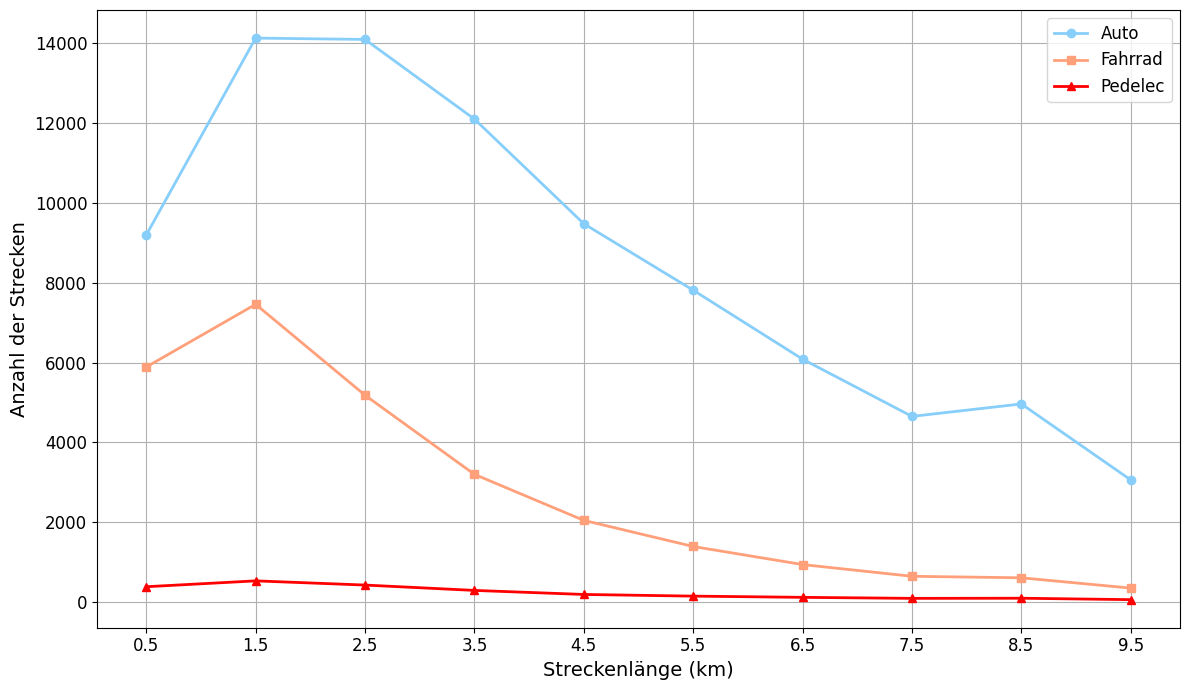

In [29]:
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('MiD17_Final.csv')
# Daten für Auto, Fahrrad und Pedelec filtern
auto_data = data[data['Mode_Choice_Car'] == 1]['wegkm_imp']
bici_data = data[data['Mode_Choice_Bici'] == 1]['wegkm_imp']
pedelec_data = data[data['Mode_Choice_Pedelec'] == 1]['wegkm_imp']

# Intervallgrenzen für die angepassten Intervalle definieren
adjusted_intervals = np.arange(0, max(data['wegkm_imp']) + 1, 1)
adjusted_centers = (adjusted_intervals[:-1] + adjusted_intervals[1:]) / 2  # Zentren der Intervalle für die X-Achse

# Funktion zum Berechnen der Anzahl von Strecken in jedem Intervall
def calculate_counts(data, intervals):
    counts = np.histogram(data, bins=intervals)[0]  # Anzahl der Strecken in jedem Intervall
    return counts

# Anzahl von Strecken für jedes Verkehrsmittel berechnen
auto_counts = calculate_counts(auto_data, adjusted_intervals)
bici_counts = calculate_counts(bici_data, adjusted_intervals)
pedelec_counts = calculate_counts(pedelec_data, adjusted_intervals)


# Funktion zum Berechnen des gleitenden Durchschnitts
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')

# Gleitenden Durchschnitt für jedes Verkehrsmittel berechnen
window_size = 3  # Fenstergröße für den gleitenden Durchschnitt
auto_smoothed = moving_average(auto_counts, window_size)
bici_smoothed = moving_average(bici_counts, window_size)
pedelec_smoothed = moving_average(pedelec_counts, window_size)


# Schriftgrößen einstellen
plt.rcParams['axes.labelsize'] = 14  # Achsenbeschriftungen
plt.rcParams['xtick.labelsize'] = 12  # X-Achsen-Ticks
plt.rcParams['ytick.labelsize'] = 12  # Y-Achsen-Ticks
plt.rcParams['legend.fontsize'] = 12  # Legende

colors = ['#FFA07A', '#FF0000', '#87CEFA']
# Geglättete Liniendiagramme erstellen
plt.figure(figsize=(12, 7))
plt.plot(adjusted_centers, auto_smoothed, label='Auto', linestyle='-', linewidth=2, marker='o', color=colors[2])
plt.plot(adjusted_centers, bici_smoothed, label='Fahrrad', linestyle='-', linewidth=2, marker='s', color=colors[0])
plt.plot(adjusted_centers, pedelec_smoothed, label='Pedelec', linestyle='-', linewidth=2, marker='^', color=colors[1])
plt.xlabel('Streckenlänge (km)')
plt.ylabel('Anzahl der Strecken')
plt.xticks(adjusted_centers)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
